In [2]:
from micrograd.engine import Value

In [3]:
import sys
sys.executable

'/opt/homebrew/anaconda3/envs/transformer/bin/python'

In [19]:
a = Value(-4.0)
b = Value(2.0)
c = a+b
d = a*b + b**3
# c += c+1
# c+= 1+c+(-a)
# d+= d*2+(b+a).relu()
# d+=3*d +(b-a).relu()
# e=c-d
# f=e**2
# g=f/2.0
# g+=10.0/f
# print(f'{g.data:.4f}')
d.backward()
print(f'{a.grad:.4f}')
print(f'{b.grad:.4f}')

2.0000
8.0000


In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def f(x):
    return 3*x**2 - 4*x + 5

In [35]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

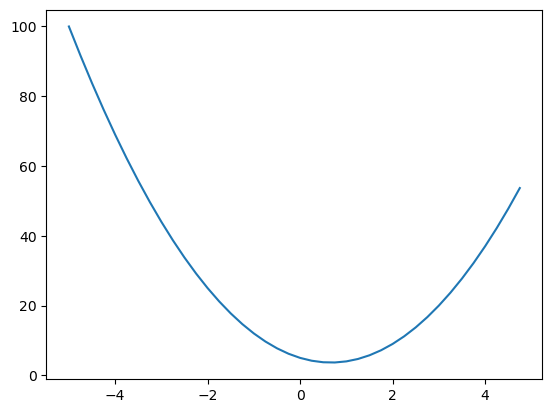

In [36]:
plt.plot(xs, ys)

In [462]:
class Value:
    def __init__(self, data, _children=(), _op = '', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label=label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    
    # 덧셈 (왼쪽/오른쪽 연산을 모두 처리하기 위해 __add__와 동일하게 처리)
    def __radd__(self, other):
        # 결국 self.__add__(other)를 호출하여 그래프를 구축
        return self + other
    
    def __neg__(self):
        return self * -1
        
    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) +1)
        out = Value(t, (self,),'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        
# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')
# e=a*b; e.label='e'
# d=e+c; d.label='d'
# f = Value(-2.0, label='f')
# L = d * f; L.label='L'

In [376]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

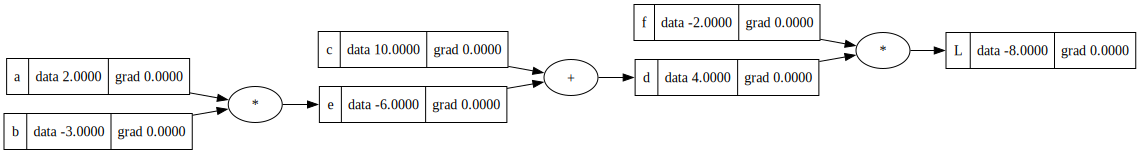

In [305]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) #LR = left to right
    
    nodes, edges = trace(root)
#     print("--- Nodes ---")
#     for node in nodes:
#         # Value 객체의 __repr__ 결과가 출력됩니다.
#         print(node)

#     print("\n--- Edges ---")
#     for n1, n2 in edges:
#         # 각 엣지 (n1, n2)를 'n1 -> n2' 형태로 출력하여 가독성을 높입니다.
#         print(f"{n1} -> {n2}")
        
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        
        if n._op:
            # if this value is a result of some operation, create an op node for it
#             print(n)
#             print(uid + n._op)
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
             
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
#     print(nodes)
#     print(edges)
    return dot
draw_dot(L)    

In [213]:
def lol():
    
    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d=e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data
    
    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d=e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data
    print((L2-L1)/h)
    
lol()

6.000000000021544


In [344]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8814, label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh()

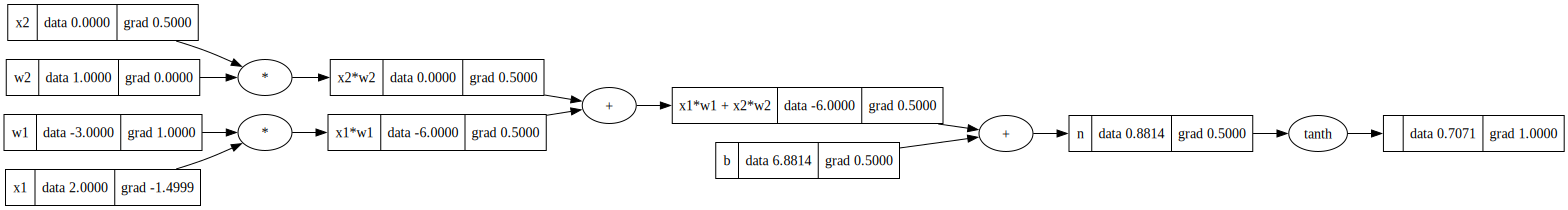

In [346]:
o.backward()
draw_dot(o)

In [379]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8814, label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
# ----
e = (2*n).exp()
o = (e - 1) / (e+1)
# ---- 
o.label = 'o'
o.backward()

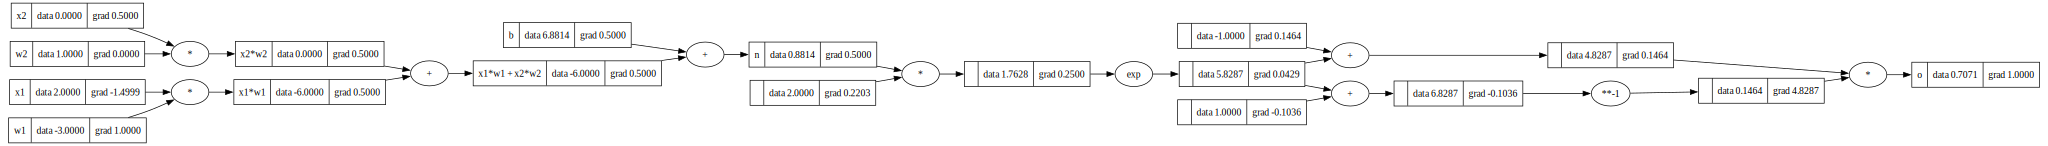

In [380]:
draw_dot(o)

In [404]:
import torch

x1 = torch.Tensor([2.0]).double()             ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()             ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()            ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()             ; w2.requires_grad = True
b = torch.Tensor([6.881373587]).double()      ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [620]:
import random
random.seed(42)
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        # w * x + b

        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) ==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [625]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.6994093620224068)

In [664]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]


In [665]:
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.18963852534076173)

In [666]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)

0 6.461259658735726
1 4.584421025487547
2 3.4553381321772734
3 2.7864351342449964
4 2.080771895278562
5 1.3820646403128172
6 0.8294719845375758
7 0.4944134689184192
8 0.31147252991981333
9 0.21722700013999163
10 0.16505098993702613
11 0.13148196148341265
12 0.10840813911566644
13 0.09173419704167635
14 0.07920360745807714
15 0.06948786337404975
16 0.061760949568769916
17 0.05548551736267074
18 0.050298517822316036
19 0.04594668086540559


In [657]:
ypred

[Value(data=0.999999999999955),
 Value(data=-1.0),
 Value(data=-1.0),
 Value(data=0.9999999999999852)]

In [627]:
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=5.230517512042234)

In [645]:
loss.backward()
for p in n.parameters():
    p.data += -0.01 * p.grad

In [646]:
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=1.147031024153204)

In [642]:
loss.backward()

In [580]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [581]:
n.layers[0].neurons[0].w[0].data

0.8642726500413784

In [647]:
ypred

[Value(data=0.976393582552813),
 Value(data=-0.9262346588416179),
 Value(data=0.06778181902662714),
 Value(data=0.9704293623929373)]

In [562]:
n.layers[0].neurons[0].w[0].grad

-1.3722609374247599

In [549]:
xs

[[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]]

In [550]:
[n(x) for x in xs]

[Value(data=0.6994093620224068),
 Value(data=0.5026295816615511),
 Value(data=0.6931545900944501),
 Value(data=0.8755224728708613)]

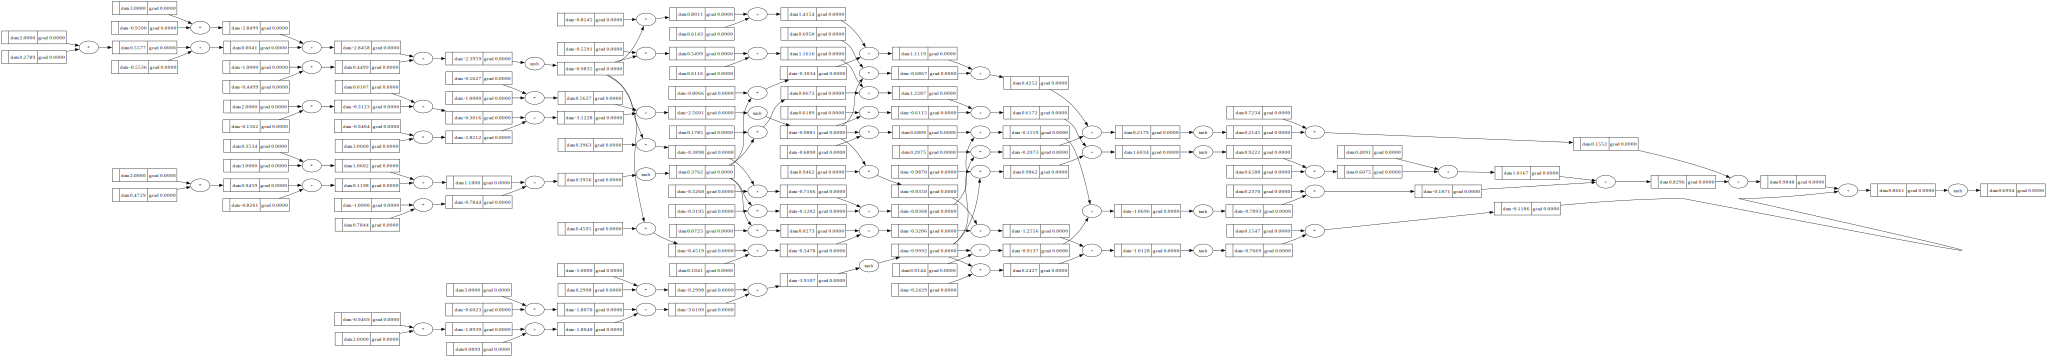

In [540]:
draw_dot(n(x))